## Objective
Develop a machine learning model to **predict freight costs** for vendor invoices based on shipment quantity and invoice value, enabling more accurate cost forecasting and procurement planning.

## Business Impact
- Freight cost is a significant component of total landed cost
- Inaccurate freight estimates can negatively impact profit margins and inventory planning
- Automated freight prediction allows procurement teams to estimate total costs **before** invoices are received
- Improved forecasting supports budgeting, supplier evaluation, and vendor negotiation strategies

## Pipeline Overview
```
Data Loading → EDA → Feature Engineering → Model Selection → Tuning → Save Model
```

---
## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

---
## 2. Load Data

In [2]:
df = pd.read_csv('../data/vendor_invoice.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (5543, 10)


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   str    
 2   InvoiceDate   5543 non-null   str    
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   str    
 5   PayDate       5543 non-null   str    
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 433.2 KB


---
## 3. Exploratory Data Analysis

Before building any model, we explore the data to understand distributions, correlations, and potential signals for predicting freight cost.

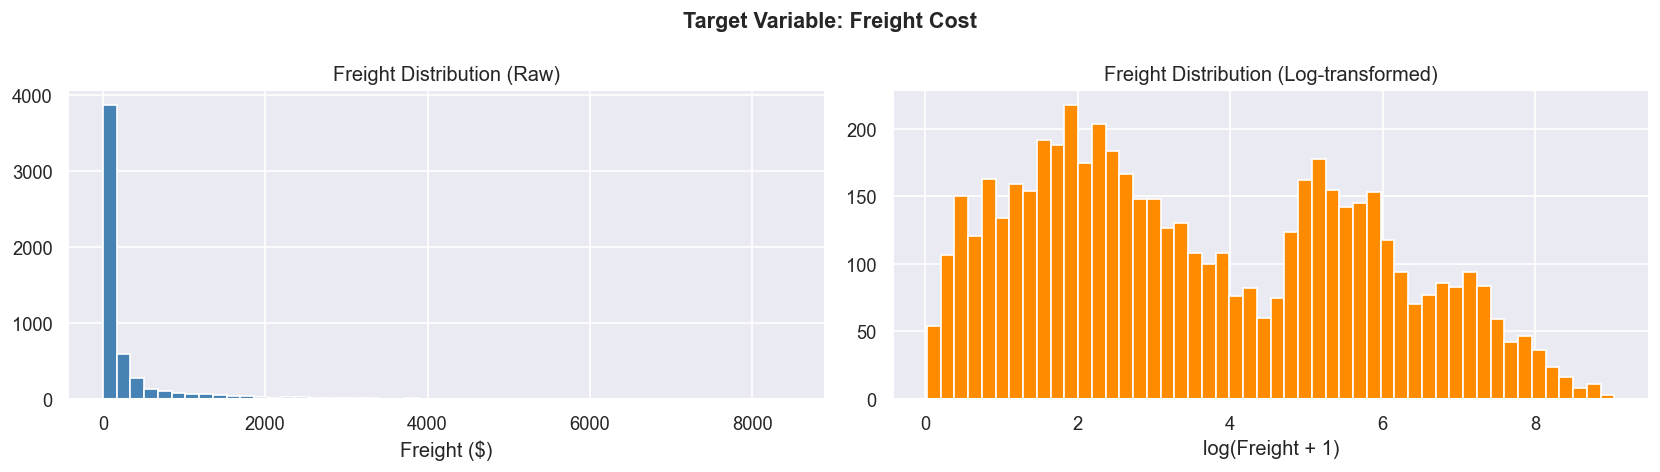

Raw Freight stats:
count    5543.00
mean      295.95
std       713.59
min         0.02
25%         5.02
50%        24.73
75%       229.66
max      8468.22
Name: Freight, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Freight'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Freight Distribution (Raw)')
axes[0].set_xlabel('Freight ($)')

axes[1].hist(np.log1p(df['Freight']), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Freight Distribution (Log-transformed)')
axes[1].set_xlabel('log(Freight + 1)')

plt.suptitle('Target Variable: Freight Cost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Raw Freight stats:")
print(df['Freight'].describe().round(2))

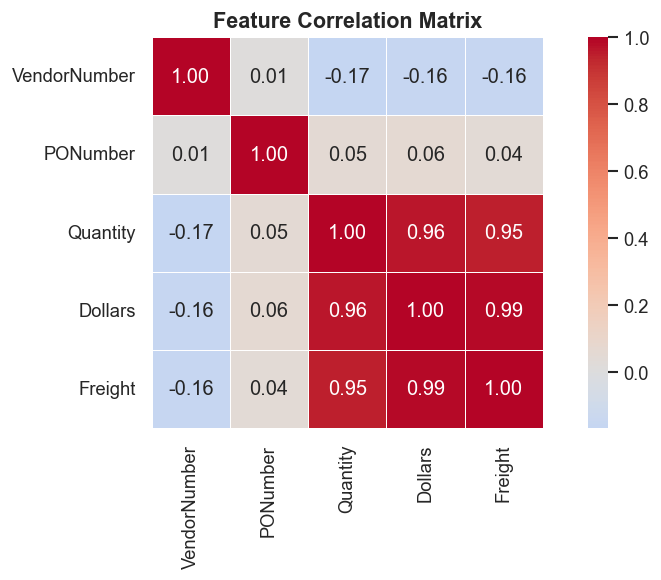

In [5]:
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Key Insight:** `Dollars` has high correlation with `Freight` → strong predictor. `Quantity` is highly correlated with `Dollars` → we drop `Quantity` to avoid multicollinearity.

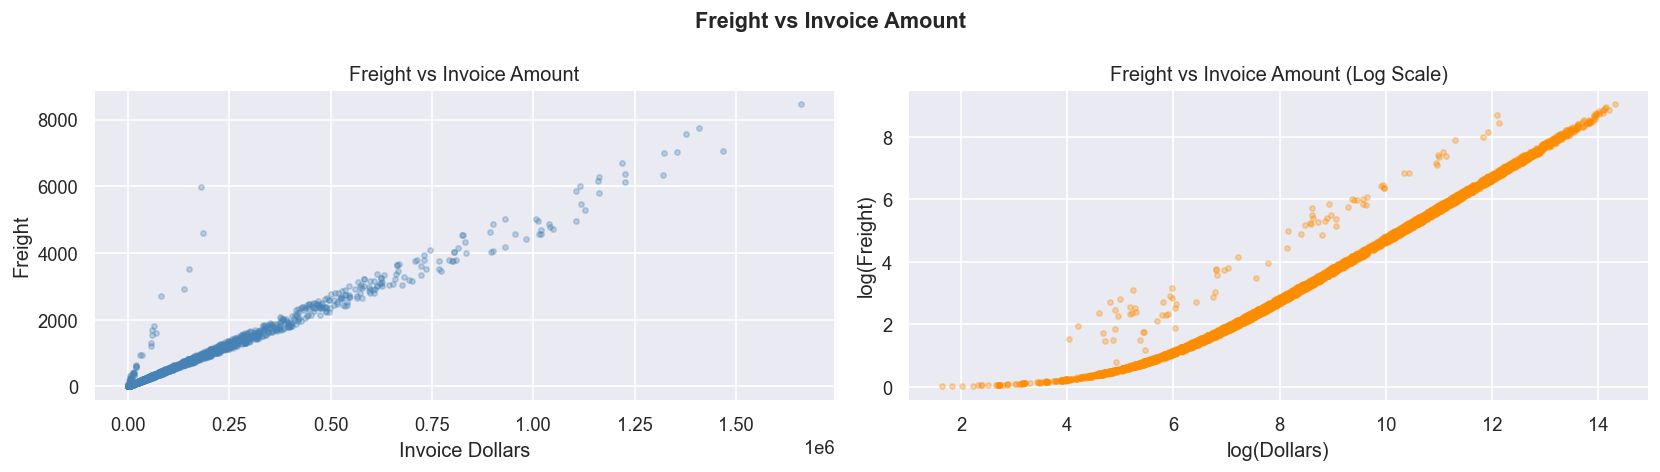

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(df['Dollars'], df['Freight'], alpha=0.3, color='steelblue', s=10)
axes[0].set_xlabel('Invoice Dollars')
axes[0].set_ylabel('Freight')
axes[0].set_title('Freight vs Invoice Amount')

axes[1].scatter(np.log1p(df['Dollars']), np.log1p(df['Freight']), alpha=0.3, color='darkorange', s=10)
axes[1].set_xlabel('log(Dollars)')
axes[1].set_ylabel('log(Freight)')
axes[1].set_title('Freight vs Invoice Amount (Log Scale)')

plt.suptitle('Freight vs Invoice Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

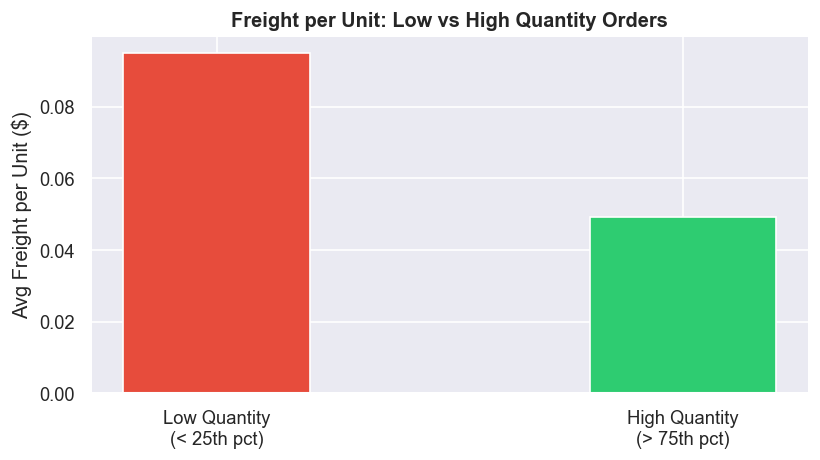

Low qty  avg freight/unit : $0.0949
High qty avg freight/unit : $0.0491


In [7]:
df['Freight_per_unit'] = df['Freight'] / df['Quantity']
low_qty  = df['Quantity'].quantile(0.25)
high_qty = df['Quantity'].quantile(0.75)

low_fpu  = df.loc[df['Quantity'] < low_qty,  'Freight_per_unit'].mean()
high_fpu = df.loc[df['Quantity'] > high_qty, 'Freight_per_unit'].mean()

plt.figure(figsize=(7, 4))
plt.bar(['Low Quantity\n(< 25th pct)', 'High Quantity\n(> 75th pct)'],
        [low_fpu, high_fpu], color=['#e74c3c', '#2ecc71'], width=0.4)
plt.ylabel('Avg Freight per Unit ($)')
plt.title('Freight per Unit: Low vs High Quantity Orders', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Low qty  avg freight/unit : ${low_fpu:.4f}")
print(f"High qty avg freight/unit : ${high_fpu:.4f}")

> **Insight:** Higher quantity orders have lower freight per unit — economies of scale in shipping.

---
## 4. Feature Engineering

We engineer date-based features to capture timing patterns that may influence freight cost.

In [8]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['PODate']      = pd.to_datetime(df['PODate'])
df['PayDate']     = pd.to_datetime(df['PayDate'])

df['invoice_to_pay']  = (df['PayDate']     - df['InvoiceDate']).dt.days
df['po_to_invoice']   = (df['InvoiceDate'] - df['PODate']).dt.days
df['po_to_pay']       = (df['PayDate']     - df['PODate']).dt.days

print("Date features created:")
df[['invoice_to_pay', 'po_to_invoice', 'po_to_pay']].describe().round(2)

Date features created:


,invoice_to_pay,po_to_invoice,po_to_pay
count,5543.00,5543.00,5543.00
mean,35.47,16.42,51.89
std,5.84,3.13,5.51
min,23.00,9.00,40.00
25%,31.00,14.00,47.00
50%,35.00,16.00,52.00
75%,40.00,19.00,56.00
max,48.00,23.00,63.00


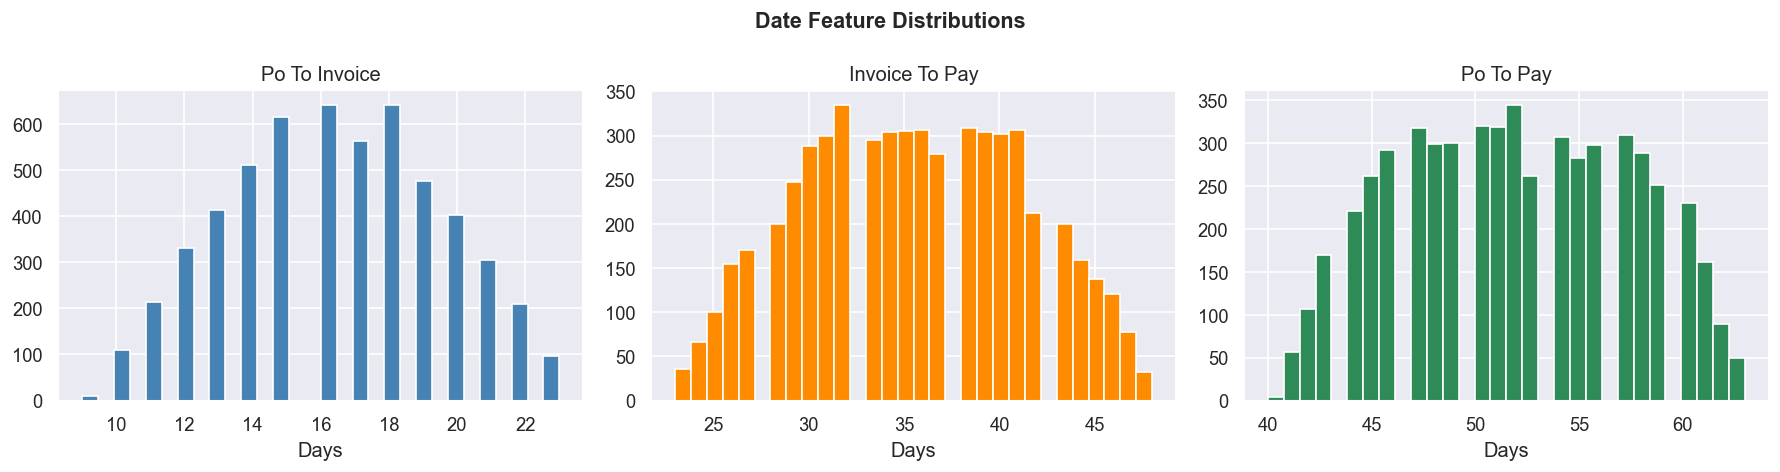

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, color in zip(axes,
                           ['po_to_invoice', 'invoice_to_pay', 'po_to_pay'],
                           ['steelblue', 'darkorange', 'seagreen']):
    ax.hist(df[col].dropna(), bins=30, color=color, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Days')

plt.suptitle('Date Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Prepare Features

**Why drop `Quantity`?** It has high correlation with `Dollars` — keeping both causes multicollinearity. `Dollars` has stronger direct correlation with `Freight` so we keep it.

**Why log-transform the target?** Freight is right-skewed — log transform makes it more normally distributed, which helps most regression models.

In [10]:
drop_cols = ['InvoiceDate', 'PODate', 'PayDate',
             'VendorName', 'Approval',
             'VendorNumber', 'PONumber',
             'Quantity',
             'Freight_per_unit']

X = df.drop(columns=drop_cols + ['Freight'])
y = np.log1p(df['Freight'])

print("Features:", X.columns.tolist())
print("Feature dtypes:")
print(X.dtypes)
print(f"\nX shape: {X.shape} | y shape: {y.shape}")

Features: ['Dollars', 'invoice_to_pay', 'po_to_invoice', 'po_to_pay']
Feature dtypes:
Dollars           float64
invoice_to_pay      int64
po_to_invoice       int64
po_to_pay           int64
dtype: object

X shape: (5543, 4) | y shape: (5543,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (4434, 4) | Test: (1109, 4)


---
## 6. Model Comparison

We test a wide range of regression models to find the best baseline before tuning.

In [12]:
models = {
    'Ridge'           : Ridge(),
    'Lasso'           : Lasso(),
    'ElasticNet'      : ElasticNet(),
    'DecisionTree'    : DecisionTreeRegressor(random_state=42),
    'RandomForest'    : RandomForestRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'AdaBoost'        : AdaBoostRegressor(n_estimators=100, random_state=42),
    'XGBoost'         : XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'KNN'             : KNeighborsRegressor(n_neighbors=5),
    'SVR'             : SVR(kernel='rbf'),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_hat = model.predict(X_test)
    results.append({
        'Model': name,
        'R2'  : round(r2_score(y_test, y_hat), 4),
        'MAE' : round(mean_absolute_error(y_test, y_hat), 4)
    })

result_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
result_df

,Model,R2,MAE
0,GradientBoosting,0.9897,0.0859
1,KNN,0.9884,0.0963
2,XGBoost,0.9868,0.1043
3,RandomForest,0.9868,0.0982
4,DecisionTree,0.9789,0.1179
5,AdaBoost,0.9698,0.3103
6,SVR,0.8999,0.5113
7,Lasso,0.4234,1.4430
8,ElasticNet,0.4234,1.4430
9,Ridge,0.4228,1.4440


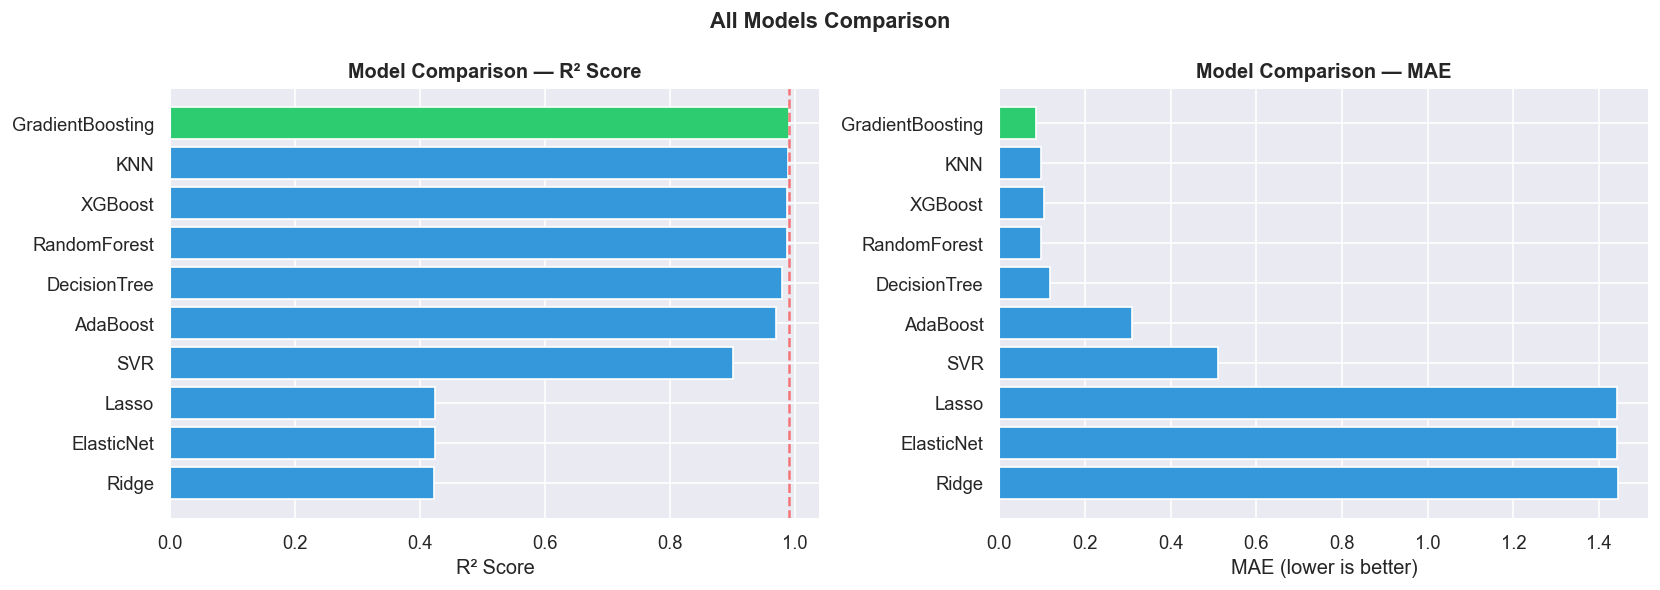

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(result_df))]

axes[0].barh(result_df['Model'], result_df['R2'], color=colors)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison — R² Score', fontweight='bold')
axes[0].axvline(x=result_df['R2'].max(), color='red', linestyle='--', alpha=0.5)
axes[0].invert_yaxis()

axes[1].barh(result_df['Model'], result_df['MAE'], color=colors)
axes[1].set_xlabel('MAE (lower is better)')
axes[1].set_title('Model Comparison — MAE', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('All Models Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Overfitting Check — GradientBoosting

Before tuning, we check if the best model is overfitting by comparing train vs test R².

Train R²: 0.9923
Test  R²: 0.9897
Gap     : 0.0026


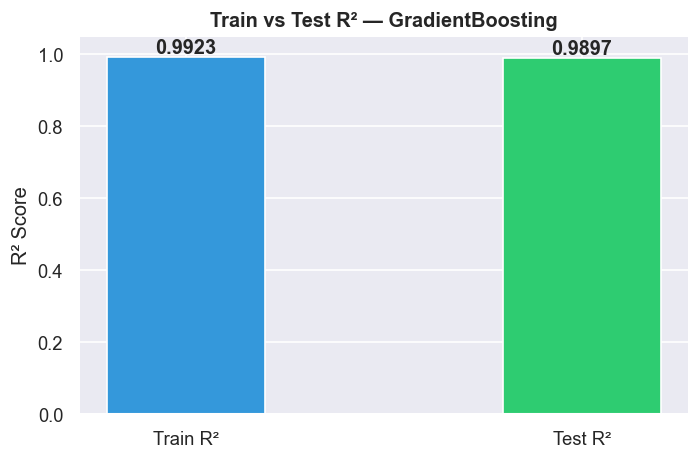

In [14]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

train_r2 = r2_score(y_train, gb.predict(X_train))
test_r2  = r2_score(y_test,  gb.predict(X_test))

print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"Gap     : {train_r2 - test_r2:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(['Train R²', 'Test R²'], [train_r2, test_r2], color=['#3498db', '#2ecc71'], width=0.4)
plt.ylim(0, 1.05)
plt.title('Train vs Test R² — GradientBoosting', fontweight='bold')
plt.ylabel('R² Score')
for i, v in enumerate([train_r2, test_r2]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Tuning — GridSearchCV

In [15]:
param_grid = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.05, 0.1, 0.2],
    'max_depth'     : [3, 4, 5],
    'subsample'     : [0.8, 1.0],
}

grid = GridSearchCV(
    estimator  = GradientBoostingRegressor(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'r2',
    verbose    = 1,
    n_jobs     = -1
)

grid.fit(X_train, y_train)

print("Best Params :", grid.best_params_)
print("Best CV R²  :", round(grid.best_score_, 4))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV R²  : 0.9902


In [16]:
best_model = grid.best_estimator_
y_pred     = best_model.predict(X_test)

print("=== Tuned GradientBoosting ===")
print(f"Test  R²  : {r2_score(y_test, y_pred):.4f}")
print(f"Train R²  : {r2_score(y_train, best_model.predict(X_train)):.4f}")
print(f"MAE       : {mean_absolute_error(y_test, y_pred):.4f}")

=== Tuned GradientBoosting ===
Test  R²  : 0.9897
Train R²  : 0.9915
MAE       : 0.0874


---
## 9. Model Evaluation & Visualization

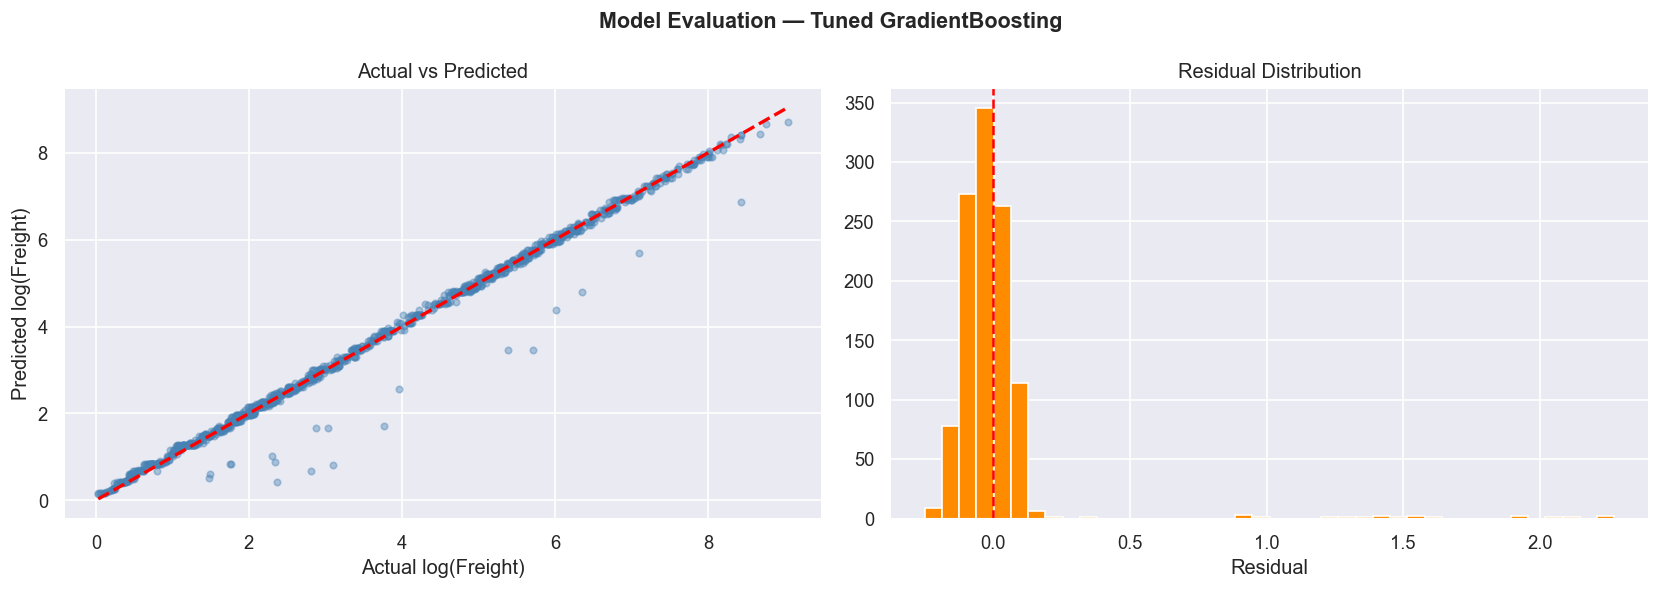

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=15)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual log(Freight)')
axes[0].set_ylabel('Predicted log(Freight)')
axes[0].set_title('Actual vs Predicted')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='darkorange', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution')

plt.suptitle('Model Evaluation — Tuned GradientBoosting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

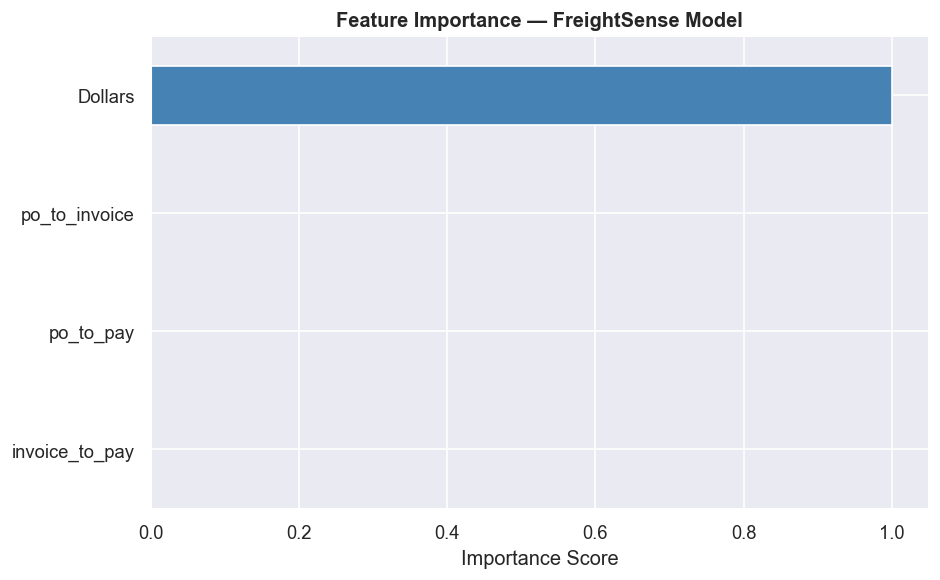

In [18]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — FreightSense Model', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [19]:
print("Target (log Freight) stats:")
print(y.describe().round(4))

Target (log Freight) stats:
count    5543.0000
mean        3.6258
std         2.1892
min         0.0198
25%         1.7951
50%         3.2477
75%         5.4409
max         9.0442
Name: Freight, dtype: float64


---
## 10. Save Model

In [20]:
import joblib

joblib.dump(best_model, '../models/freight_predictor_gb.pkl')

['../models/freight_predictor_gb.pkl']